In [1]:
#  Compare classification results from diff on sklearn load_digits data set

import sklearn.datasets

digits = sklearn.datasets.load_digits()

print(type(digits))
print(*digits.keys(), sep="\n")

<class 'sklearn.utils._bunch.Bunch'>
data
target
frame
feature_names
target_names
images
DESCR


{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)), 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)), 'frame': None, 'feature_names': ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_

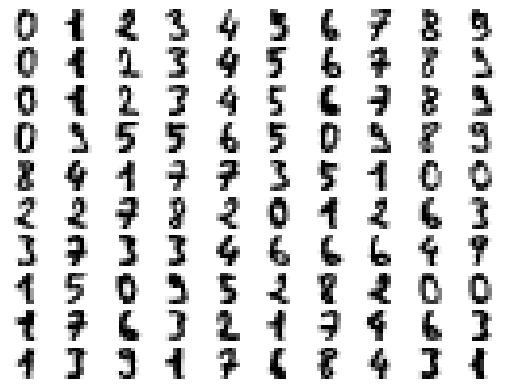

In [ ]:
# print(digits)

#  display the first image and its label
import matplotlib.pyplot as plt
digits = sklearn.datasets.load_digits(as_frame=True)
df = digits.frame
fig, axes = plt.subplots(10,10)

for ax, (idx, row) in zip(axes.ravel(), df[digits.feature_names].iterrows()):
    image = row.to_numpy().reshape(8, 8)
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
plt.show()

In [10]:
#  Fit svm
import sklearn.svm
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42
)

svc = sklearn.svm.SVC(
    gamma=0.001,
    class_weight="balanced",
    C = 100
)

svc.fit(X = X_train, y = y_train)

print(svc)

SVC(C=100, class_weight='balanced', gamma=0.001)


In [3]:
# Fit svn for classification and display evaluation metrics
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.2)
model = svm.SVC(gamma=0.001)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[35  0  0  0  0  0  0  0  0  0]
 [ 0 32  0  0  0  0  0  0  0  0]
 [ 0  0 36  0  0  0  0  0  0  0]
 [ 0  0  0 28  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 33  0  0  0  0]
 [ 0  0  0  0  0  0 43  0  0  0]
 [ 0  0  0  0  0  0  0 42  0  0]
 [ 0  1  0  0  0  0  0  0 29  0]
 [ 0  0  0  1  0  1  0  0  0 32]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.97      1.00      0.98        32
           2       1.00      1.00      1.00        36
           3       0.97      0.97      0.97        29
           4       1.00      1.00      1.00        46
           5       0.94      1.00      0.97        33
           6       1.00      1.00      1.00        43
           7       1.00      1.00      1.00        42
           8       1.00      0.97      0.98        30
           9       1.00      0.94      0.97        34

    accuracy                           0.99       360
   macro avg       

In [4]:
#  Fit KNN for classification and display evaluation metrics
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[35  0  0  0  0  0  0  0  0  0]
 [ 0 32  0  0  0  0  0  0  0  0]
 [ 0  0 36  0  0  0  0  0  0  0]
 [ 0  0  0 29  0  0  0  0  0  0]
 [ 0  1  0  0 44  0  0  1  0  0]
 [ 0  0  0  0  0 33  0  0  0  0]
 [ 0  0  0  0  0  0 43  0  0  0]
 [ 0  0  0  0  0  0  0 42  0  0]
 [ 0  1  0  0  0  0  0  0 29  0]
 [ 0  0  0  1  0  1  0  0  1 31]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       0.94      1.00      0.97        32
           2       1.00      1.00      1.00        36
           3       0.97      1.00      0.98        29
           4       1.00      0.96      0.98        46
           5       0.97      1.00      0.99        33
           6       1.00      1.00      1.00        43
           7       0.98      1.00      0.99        42
           8       0.97      0.97      0.97        30
           9       1.00      0.91      0.95        34

    accuracy                           0.98       360
   macro avg       